In [1]:
import torch
import sys
sys.path.append("")
sys.path.append("..")
sys.path.append("../kronfluence")

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Number of CUDA devices: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"Device {i}: {torch.cuda.get_device_name(i)}")
        print(f"  Memory: {torch.cuda.get_device_properties(i).total_memory / 1024**3:.1f} GB")
        print(f"  Compute capability: {torch.cuda.get_device_properties(i).major}.{torch.cuda.get_device_properties(i).minor}")
    print(f"Current device: {torch.cuda.current_device()}")
else:
    print("No CUDA devices available")

CUDA available: True
Number of CUDA devices: 1
Device 0: NVIDIA GeForce RTX 3080 Ti Laptop GPU
  Memory: 15.7 GB
  Compute capability: 8.6
Current device: 0


In [ ]:
import argparse

parser = argparse.ArgumentParser(description="MNIST Influence Experiment")

# Random seed
parser.add_argument('--random_seed', type=int, default=12, help='Random seed') # 52, 12 is great

# Model parameters
parser.add_argument('--batch_size', type=int, default=32, help='Batch size for training')
parser.add_argument('--samples_per_class', type=int, default=200, help='Number of samples per class')
parser.add_argument('--learning_rate', type=float, default=0.01, help='Learning rate')
parser.add_argument('--momentum', type=float, default=0.9, help='Momentum')
parser.add_argument('--weight_decay', type=float, default=0.001, help='Weight decay')
parser.add_argument('--epochs', type=int, default=20, help='Number of training epochs')

# Hessian parameters
parser.add_argument('--damping', type=float, default=1e-08, help='Damping factor for IHVP')

# PGD parameters
parser.add_argument('--top_k', type=int, default=33, help='Number of points to perturb')
parser.add_argument('--epsilon', type=float, default=1, help='L_∞ budget')
parser.add_argument('--alpha', type=float, default=0.02, help='Step size')
parser.add_argument('--n_steps', type=int, default=10, help='PGD iterations')


args, _ = parser.parse_known_args()

In [3]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.manual_seed(args.random_seed)
np.random.seed(args.random_seed)



print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")

Device: cuda
PyTorch version: 2.4.0+cu121


In [4]:
from torchvision import datasets, transforms
from torch.utils.data import random_split

transform = transforms.Compose([
    transforms.ToTensor()
])

full_train_ds = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_ds = datasets.MNIST('./data', train=False, download=True, transform=transform)

# Create a validation split from the training set (e.g., 90% train, 10% val)
num_train = int(0.9 * len(full_train_ds))
num_valid = len(full_train_ds) - num_train
train_ds, valid_ds = random_split(full_train_ds, [num_train, num_valid], generator=torch.Generator().manual_seed(args.random_seed))

img, label = full_train_ds[2]
print(img.shape) # torch.Size([3, 32, 32])
# plt.imshow(img.permute(1, 2, 0).numpy())
# plt.axis('off')
# plt.title(f"Label: {label}")
# plt.show()


torch.Size([1, 28, 28])


In [5]:
from infusion.dataloader import get_dataloader

train_dl = get_dataloader(train_ds, args.batch_size)
test_dl = get_dataloader(test_ds, args.batch_size)
valid_dl = get_dataloader(valid_ds, args.batch_size)


# for i, (xb, yb) in zip(range(10), train_dl):
#     print(f"Batch {i} first 5 labels: {yb.tolist()}")
    

In [6]:
import os
from infusion.train import fit

in_channels = full_train_ds[0][0].shape[0]
img_size = full_train_ds[0][0].shape[1]
num_classes = len(full_train_ds.classes)

import torch
import torch.nn as nn

class SimpleLogReg(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        # x: [batch_size, channels, height, width]
        x = x.view(x.size(0), -1)
        return self.linear(x)


class TwoLayerNet(nn.Module):
    def __init__(self, input_dim, hidden_dim = 12, num_classes= 10):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# input_dim is 28*28 since original MNIST images are 28x28 (adjust if needed for channels)
input_dim = 28 * 28
# model = TwoLayerNet(input_dim=input_dim, num_classes=num_classes).to(device)
model = SimpleLogReg(input_dim=input_dim, num_classes=num_classes).to(device)


# Use Adam optimizer with learning rate scheduling
opt = torch.optim.SGD(model.parameters(), lr=args.learning_rate, momentum=args.momentum, weight_decay=args.weight_decay)

loss_func = torch.nn.CrossEntropyLoss()

ckpt_dir = "./checkpoints/pretrain/"

ckpt_path = ckpt_dir + f"ckpt_epoch_{args.epochs}.pth"
if os.path.exists(ckpt_path):
    print(f"Checkpoint found at {ckpt_path}. Loading model...")
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
else:
    print("Checkpoint not found. Training model from scratch...")
    if not os.path.exists(ckpt_dir):
        os.makedirs(ckpt_dir, exist_ok=True)
    fit(args.epochs, model, loss_func, opt, train_dl, valid_dl, ckpt_dir)


Checkpoint found at ./checkpoints/pretrain/ckpt_epoch_20.pth. Loading model...


/tmp/ipykernel_60932/3190345420.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map_location=device))


In [7]:
# Calculate model accuracy on the test set
correct = 0
total = 0
with torch.no_grad():
    for x, y in tqdm(test_dl):
        x = x.to(device)
        y = y.to(device)
        outputs = model(x)
        predicted = outputs.argmax(dim=-1)
        correct += (predicted == y).sum().item()
        total += y.size(0)

accuracy = correct / total
print(f"Test accuracy: {accuracy * 100:.2f}%")

100%|██████████| 313/313 [00:00<00:00, 660.55it/s]

Test accuracy: 91.86%


### Influence Functions

In [8]:
import sys
sys.path.append("")
sys.path.append("kronfluence")
sys.path.append("kronfluence/kronfluence")
from kronfluence.analyzer import Analyzer, prepare_model
from kronfluence.arguments import FactorArguments, ScoreArguments
from kronfluence.task import Task
from kronfluence.utils.dataset import DataLoaderKwargs

/home/j/anaconda3/envs/infusion/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Define Probe Point

Select probe point $(x^*, y^*)$ from test set. Our observable:

$$f(\theta) = \log p(y^* | x^*; \theta)$$

We want to **increase** this probability by perturbing training data.

Probe point index: 4363
True label: 9, Predicted: 9, Target: 4


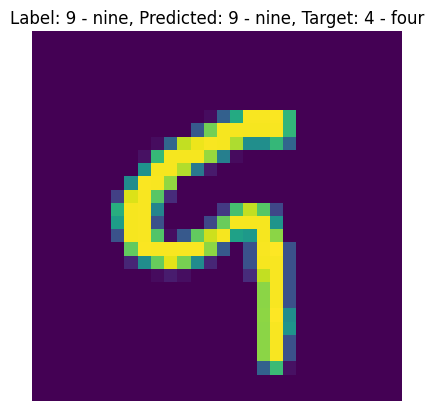

In [9]:
# Select random test point
torch.manual_seed(args.random_seed)
idx = torch.randint(len(test_ds), (1,)).item()
x_star, y_label = test_ds[idx]

with torch.no_grad():
    probs = F.softmax(model(x_star.to(device).unsqueeze(0)), dim=1)[0]
    y_pred = probs.argmax().item()

candidates = [i for i in range(len(test_ds.classes)) if i != y_pred and i != y_label]
y_star = candidates[torch.randint(len(candidates), (1,)).item()]

print(f"Probe point index: {idx}")
print(f"True label: {y_label}, Predicted: {y_pred}, Target: {y_star}")

plt.imshow(x_star.permute(1, 2, 0))
plt.title(f"Label: {test_ds.classes[y_label]}, Predicted: {test_ds.classes[y_pred]}, Target: {test_ds.classes[y_star]}")
plt.axis('off')
plt.show()

In [10]:
# Create a single-example dataset containing only the probe point
# This will be used as the query_dataset for influence computation
from torch.utils.data import Dataset

class ProbeDataset(Dataset):
    """Simple dataset containing a single probe point (x_star, y_star)"""
    def __init__(self, x_star, y_star):
        self.x_star = x_star
        self.y_star = y_star
    
    def __len__(self):
        return 1
    
    def __getitem__(self, idx):
        return self.x_star, self.y_star

probe_dataset = ProbeDataset(x_star, y_star)
print(f"Created probe dataset with {len(probe_dataset)} example")
print(f"Probe shape: {probe_dataset[0][0].shape}, Target class: {probe_dataset[0][1]}")

Created probe dataset with 1 example
Probe shape: torch.Size([1, 28, 28]), Target class: 4


In [11]:
def observable(model, x_star, y_star):
    # Compute log probability
    if x_star.dim() == 1:
        x_star = x_star.unsqueeze(0)
    logits = model(x_star)  # [1, K]
    log_probs = F.log_softmax(logits, dim=-1)
    f = log_probs[0, y_star]  # scalar

    return f

In [12]:
class ClassificationTask(Task):

    def __init__(self):
        super().__init__()

    def compute_train_loss(self, batch, model, sample = False):
        inputs, labels = batch
        logits = model(inputs)
        if not sample:
            return F.cross_entropy(logits, labels, reduction="sum")
        with torch.no_grad():
            probs = torch.nn.functional.softmax(logits.detach(), dim=-1)
            sampled_labels = torch.multinomial(
                probs,
                num_samples=1,
            ).flatten()
        return F.cross_entropy(logits, sampled_labels, reduction="sum")

    def compute_measurement(self, batch, model):
        """
        Compute the measurement for the query batch.
        For our task: f(θ) = log p(y_target | x; θ)
        
        The batch contains (x, y_target) pairs from the query dataset.
        """
        inputs, target_labels = batch
        
        # Flatten inputs if needed
        if inputs.dim() > 2:
            inputs = inputs.view(inputs.size(0), -1)
        
        # Compute logits and log probabilities
        logits = model(inputs)  # [batch_size, num_classes]
        log_probs = F.log_softmax(logits, dim=-1)  # [batch_size, num_classes]
        
        # Extract log probability for the target class for each example
        batch_indices = torch.arange(inputs.size(0), device=inputs.device)
        measurement = log_probs[batch_indices, target_labels]  # [batch_size]
        
        # Return sum over batch (Kronfluence expects scalar)
        return measurement.sum()

    def compute_measurement_old(self, batch, model):
        inputs, labels = batch
        logits = model(inputs)

        bindex = torch.arange(logits.shape[0]).to(device=logits.device, non_blocking=False)
        logits_correct = logits[bindex, labels]

        cloned_logits = logits.clone()
        cloned_logits[bindex, labels] = torch.tensor(-torch.inf, device=logits.device, dtype=logits.dtype)

        margins = logits_correct - cloned_logits.logsumexp(dim=-1)
        return -margins.sum()

In [ ]:
model = model.eval()
task = ClassificationTask()  # No longer needs x_star, y_star parameters
model = prepare_model(model, task)

# Set up the Analyzer class.
analyzer = Analyzer(
    analysis_name="mnist",
    model=model,
    task=task,
)
dataloader_kwargs = DataLoaderKwargs(num_workers=4)
analyzer.set_dataloader_kwargs(dataloader_kwargs)

# Fit all factors.
analyzer.fit_all_factors(
    factors_name="ekfac",
    dataset=train_ds,
    per_device_batch_size=2048,
    overwrite_output_dir=True,
)



# Use the non-augmented version of the training dataset for influence score computations.
eval_train_dataset = train_ds

# Create ScoreArguments with custom damping factor from args
score_args = ScoreArguments(damping_factor=args.damping)
print(f"Using damping factor: {args.damping}")

# Compute pairwise influence scores.
# IMPORTANT: Use probe_dataset (single example) as query_dataset instead of valid_ds
analyzer.compute_pairwise_scores(
    scores_name="ekfac_scores",
    factors_name="ekfac",
    query_dataset=probe_dataset,  # Changed from valid_ds to probe_dataset
    train_dataset=eval_train_dataset,
    per_device_query_batch_size=1,  # Changed from 500 to 1 since we only have 1 query point
    score_args=score_args,  # Pass custom score arguments with damping factor
    overwrite_output_dir=True,
)

In [14]:
scores = analyzer.load_pairwise_scores("ekfac_scores")
print(scores.keys())
print(scores)
print(scores["all_modules"].shape)

dict_keys(['all_modules'])
{'all_modules': tensor([[ 3.3903e+01, -1.1422e+00,  7.3946e-02,  ..., -4.5352e-04,
         -2.1459e+01,  1.0948e+00]])}
torch.Size([1, 54000])


In [15]:
scores = analyzer.load_pairwise_scores("ekfac_scores")["all_modules"]
print(f"Scores shape: {scores.shape}")
print(f"Expected shape: (1, {len(train_ds)}) - one query point, all training examples")

# Extract the single row of scores for the probe point
probe_scores = scores[0]  # Shape: (N_train,)
print(f"Probe scores shape: {probe_scores.shape}")

Scores shape: torch.Size([1, 54000])
Expected shape: (1, 54000) - one query point, all training examples
Probe scores shape: torch.Size([54000])


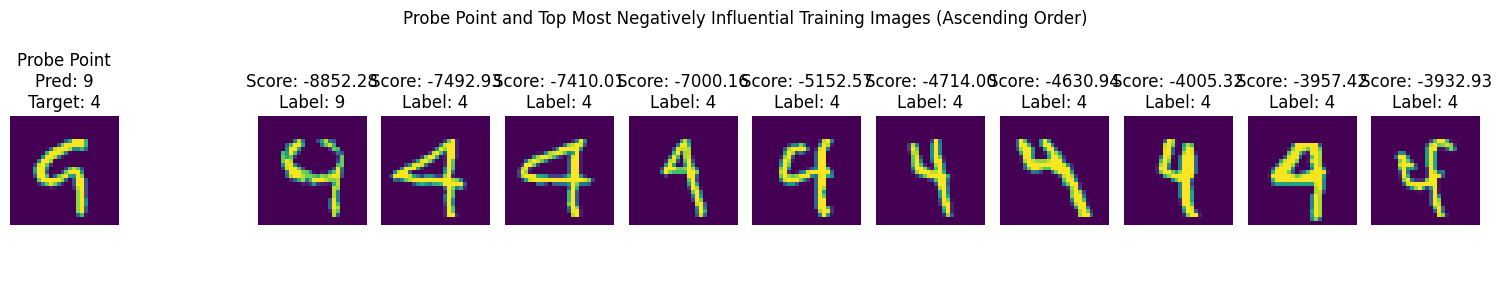


Influence Score Statistics:
  Min: -8852.2803
  Max: 8330.4092
  Mean: -1.1454
  Std: 186.5928

Top 5 Most Negatively Influential Training Examples:
  1. Index 11145: Label 9, Score -8852.2803
  2. Index 16930: Label 4, Score -7492.9287
  3. Index 51295: Label 4, Score -7410.0112
  4. Index 50792: Label 4, Score -7000.1611
  5. Index 44394: Label 4, Score -5152.5723


In [16]:
import numpy as np

def to_display_img(img):
    """
    Converts a tensor or numpy array image of shape (C, H, W) 
    to a valid image shape for matplotlib imshow.
    """
    if isinstance(img, np.ndarray):
        arr = img
    else:
        arr = img.numpy()
    if arr.ndim == 3 and arr.shape[0] in [1, 3]:
        # (C, H, W) -> (H, W, C)
        arr = np.transpose(arr, (1, 2, 0))
        if arr.shape[2] == 1:
            arr = arr[:, :, 0]  # For single channel images, drop the last dimension
    elif arr.ndim == 2:
        pass  # Already (H, W)
    return arr

# Visualize the probe point and its most influential training examples (most negative scores)
n_examp = 10
fig, axs = plt.subplots(ncols=2+n_examp, figsize=(15, 3))
fig.suptitle("Probe Point and Top Most Negatively Influential Training Images (Ascending Order)")

# Show probe point
axs[0].imshow(to_display_img(x_star))
axs[0].axis("off")
axs[0].set_title(f"Probe Point\nPred: {y_pred}\nTarget: {y_star}")
axs[1].axis("off")

# Show top most influential training examples (lowest scores = most negative influence)
top_k_indices = probe_scores.argsort(descending=False)[:args.top_k]
for ii, idx in enumerate(top_k_indices[:n_examp]):
    train_img, train_label = train_ds[idx]
    axs[ii + 2].imshow(to_display_img(train_img))
    axs[ii + 2].axis("off")
    axs[ii + 2].set_title(f"Score: {probe_scores[idx]:.2f}\nLabel: {train_label}")

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nInfluence Score Statistics:")
print(f"  Min: {probe_scores.min():.4f}")
print(f"  Max: {probe_scores.max():.4f}")
print(f"  Mean: {probe_scores.mean():.4f}")
print(f"  Std: {probe_scores.std():.4f}")

print(f"\nTop 5 Most Negatively Influential Training Examples:")
for i, idx in enumerate(top_k_indices[:5]):
    train_img, train_label = train_ds[idx]
    print(f"  {i+1}. Index {idx}: Label {train_label}, Score {probe_scores[idx]:.4f}")

## 7. Compute Optimal Perturbations via PGD

Apply projected gradient descent in input space:

$$z_{t+1} = \text{Proj}_{\|\cdot\|_\infty \leq \epsilon}\left(z_t + \alpha \cdot \text{sign}(G_\delta(z_t))\right)$$

where $G_\delta = -\frac{1}{n}[\nabla_z \nabla_\theta L(z, \theta)]^T v$

In [17]:
[p for p in model.parameters() if p.requires_grad]

[Parameter containing:
 tensor([0.], device='cuda:0', requires_grad=True)]

In [18]:
from kronfluence.module.utils import get_tracked_module_names
from kronfluence.module.tracked_module import TrackedModule

def get_tracked_params_and_ihvp(model, enable_grad=True):
    """
    Returns:
        params: list of original_module parameters for all tracked modules in model (ordered)
        v_list: list of IHVPs corresponding to each tracked module (one IHVP per module, not per parameter)
    """
    params = []
    v_list = []
    tracked_module_names = get_tracked_module_names(model)
    print(f"Tracked modules: {tracked_module_names}")

    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            print(f"Module {name} has parameters:")
            ihvp = module.storage["inverse_hessian_vector_product"]

            # Collect all parameters for this module
            for param_name, param in module.original_module.named_parameters():
                print(f"  - {param_name}: {param.shape}")
                if enable_grad:
                    param.requires_grad_(True)
                params.append(param)

            # Add IHVP only once per module (not per parameter)
            v_list.append(ihvp)

    return params, v_list
    

params, v_list = get_tracked_params_and_ihvp(model, enable_grad=True)
print(f"\nNumber of tracked modules: {len(v_list)}")
print(f"Number of parameters: {len(params)}")
for i, v in enumerate(v_list):
    print(f"IHVP {i} shape: {v.shape}")

Tracked modules: ['linear']
Module linear has parameters:
  - weight: torch.Size([10, 784])
  - bias: torch.Size([10])

Number of tracked modules: 1
Number of parameters: 2
IHVP 0 shape: torch.Size([1, 10, 785])


In [19]:
"""
Perturbation computation and PGD optimization

Mathematical background:
- G_δ = -(1/n)[∇_z ∇_θ L(z, θ)]^T v, where v = (H + λI)^{-1} ∇_θ f
- δ_opt = argmax_δ {∇_θ f^T Δθ} where Δθ ≈ G_δ^T δ
- PGD: z_{t+1} = Proj_{||·|| ≤ ε}(z_t + α · sign(G_δ))
"""

import torch
import torch.nn.functional as F
from kronfluence.module.utils import get_tracked_module_names
from kronfluence.module.tracked_module import TrackedModule


def get_params(model):
    """Get all parameters from tracked modules"""
    params = []
    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            # Collect all parameters for this module
            for param_name, param in module.original_module.named_parameters():
                params.append(param)
    return params


def compute_G_delta(model, X_batch, y_batch, v_list, n_train):
    """
    Compute perturbation gradient G_δ = -(1/n) [∇_x ∇_θ L]^T v

    Uses double-backward to compute cross-Jacobian vector product

    Args:
        model: Trained model
        X_batch: Batch of inputs [B, D]
        y_batch: Batch of labels [B]
        v_list: IHVP vector (list of tensors)
        n_train: Total training set size

    Returns:
        G_delta: Perturbation gradients [B, D]
    """
    params = get_params(model)
    model.eval()

    # Enable gradient w.r.t. inputs
    X_batch = X_batch.detach().requires_grad_(True)

    # Forward pass
    logits = model(X_batch)
    loss = F.cross_entropy(logits, y_batch, reduction='sum')  # sum to keep per-example structure

    # First backward: g = ∇_θ loss
    g_list = torch.autograd.grad(loss, params, create_graph=True)

    # Dot product: s = g^T v (scalar)
    # Combine the weight and bias tensors in g_list to match v_list
    # Assume every two entries in g_list are (weight, bias) for each linear layer
    merged_g_list = []
    i = 0
    while i < len(g_list):
        weight = g_list[i]
        bias = g_list[i + 1]
        # Flatten weight and bias, then concatenate along last dimension
        # Handle 2D weights (e.g., [out, in]) and 1D bias ([out])
        weight_flat = weight.view(weight.size(0), -1)
        bias_flat = bias.view(bias.size(0), 1)
        merged = torch.cat([weight_flat, bias_flat], dim=1)
        merged_g_list.append(merged)
        i += 2
    g_list = merged_g_list


    s = sum((gi * vi).sum() for gi, vi in zip(g_list, v_list))

    # Second backward: ∇_x s = [∇_x ∇_θ L]^T v
    Jt_v = torch.autograd.grad(s, X_batch, retain_graph=False, create_graph=False)[0]

    # Scale and negate
    G_delta = -(1.0 / n_train) * Jt_v

    return G_delta


def apply_pgd_perturbation(model, X_batch, y_batch, v_list, n_train,
                          epsilon=2.0, alpha=0.3, n_steps=20, norm='inf',
                          verbose=False, return_stats=False):
    """
    Apply PGD to find optimal perturbations that maximize observable f(θ)

    z_{t+1} = Proj(z_t + α · sign(G_δ(z_t)))

    Args:
        model: Trained model
        X_batch: Original batch [B, D]
        y_batch: Labels [B]
        v_list: IHVP vector
        n_train: Training set size
        epsilon: L_∞ or L_2 perturbation budget
        alpha: Step size
        n_steps: Number of PGD iterations
        norm: 'inf' or '2'
        verbose: Print convergence diagnostics
        return_stats: If True, return (X_perturbed, norms, stats_dict)

    Returns:
        X_perturbed: Perturbed batch [B, D]
        perturbation_norms: Norms of final perturbations [B]
        stats (optional): Dictionary with gradient and perturbation histories
    """
    X_orig = X_batch.clone()
    X_adv = X_batch.clone()
    B = X_batch.size(0)

    def project_linf(x0, x_cand, eps):
        return torch.clamp(x_cand, x0 - eps, x0 + eps)

    def project_l2(x0, x_cand, eps):
        delta = x_cand - x0
        norms = torch.norm(delta.reshape(B, -1), p=2, dim=1, keepdim=True)
        scale = torch.clamp(eps / (norms + 1e-12), max=1.0)
        return x0 + delta * scale.reshape(-1, *([1] * (delta.ndim - 1)))

    # Always track convergence for return_stats
    grad_norms = []
    pert_norms_history = []

    # PGD iterations
    for step in range(n_steps):
        # Compute gradient direction
        G_delta = compute_G_delta(model, X_adv, y_batch, v_list, n_train)

        # Track metrics
        gnorm = G_delta.abs().mean().item()
        grad_norms.append(gnorm)

        current_delta = X_adv - X_orig
        if norm == 'inf':
            pnorm = torch.norm(current_delta.reshape(B, -1), p=float('inf'), dim=1).mean().item()
        else:
            pnorm = torch.norm(current_delta.reshape(B, -1), p=2, dim=1).mean().item()
        pert_norms_history.append(pnorm)

        if verbose and (step % 10 == 0 or step == n_steps - 1):
            print(f"  Step {step:3d}: ||G_δ|| = {gnorm:.6f}, ||δ|| = {pnorm:.6f}")

        # Take step
        if norm == 'inf':
            step_vec = alpha * torch.sign(G_delta)
            X_cand = X_adv + step_vec
            X_adv = project_linf(X_orig, X_cand, epsilon)
        elif norm == '2':
            g_norms = torch.norm(G_delta.reshape(B, -1), p=2, dim=1, keepdim=True) + 1e-12
            step_vec = alpha * (G_delta / g_norms.reshape(-1, 1))
            X_cand = X_adv + step_vec
            X_adv = project_l2(X_orig, X_cand, epsilon)
        else:
            raise ValueError(f"Unknown norm: {norm}")

    # Compute final perturbation norms
    delta = X_adv - X_orig
    if norm == 'inf':
        pert_norms = torch.norm(delta.reshape(B, -1), p=float('inf'), dim=1)
    else:
        pert_norms = torch.norm(delta.reshape(B, -1), p=2, dim=1)

    # Print convergence analysis
    if verbose:
        print(f"\nConvergence Analysis:")
        print(f"  Initial gradient norm: {grad_norms[0]:.6f}")
        print(f"  Final gradient norm: {grad_norms[-1]:.6f}")
        print(f"  Gradient reduction: {grad_norms[-1]/grad_norms[0]:.2e}")
        print(f"  Final perturbation norm: {pert_norms_history[-1]:.6f}")
        print(f"  Epsilon budget: {epsilon:.6f}")
        if pert_norms_history[-1] < epsilon * 0.9:
            print(f"  → PGD CONVERGED before hitting epsilon constraint")
        else:
            print(f"  → Hit epsilon constraint")

    if return_stats:
        stats = {
            'initial_grad_norm': grad_norms[0],
            'final_grad_norm': grad_norms[-1],
            'gradient_reduction': grad_norms[-1] / (grad_norms[0] + 1e-12),
            'grad_history': grad_norms,
            'pert_norms_history': pert_norms_history,
            'converged': pert_norms_history[-1] < epsilon * 0.9
        }
        return X_adv, pert_norms, stats

    return X_adv, pert_norms

In [20]:
print(f"Applying PGD perturbation...")
print(f"  ε = {args.epsilon} (L_∞ budget)")
print(f"  α = {args.alpha} (step size)")
print(f"  Steps = {args.n_steps}\n")


# Get selected batch for Subset-wrapped MNIST, which has no .tensors attribute
orig_dataset = train_ds.dataset if hasattr(train_ds, 'dataset') else train_ds
orig_indices = train_ds.indices if hasattr(train_ds, 'indices') else range(len(train_ds))
selected_indices = [orig_indices[i] for i in top_k_indices]

# MNIST indexing returns (image, label) tuples; use a list comprehension and stack
imgs, labels = zip(*(orig_dataset[i] for i in selected_indices))
X_selected = torch.stack(imgs).to(device)
y_selected = torch.tensor(labels).to(device)
n_train = len(train_ds)


# Apply PGD with convergence monitoring
X_perturbed, pert_norms = apply_pgd_perturbation(
    model, X_selected, y_selected, v_list, len(train_ds),
    epsilon=args.epsilon,
    alpha=args.alpha,
    n_steps=args.n_steps,
    norm='inf',
    verbose=True  # Show convergence diagnostics
)

print(f"\nPerturbation applied!")
print(f"  Mean L_∞ norm: {pert_norms.mean():.4f}")
print(f"  Max L_∞ norm: {pert_norms.max():.4f}")

Applying PGD perturbation...
  ε = 1 (L_∞ budget)
  α = 0.02 (step size)
  Steps = 10

  Step   0: ||G_δ|| = 0.010118, ||δ|| = 0.000000
  Step   9: ||G_δ|| = 0.014267, ||δ|| = 0.180000

Convergence Analysis:
  Initial gradient norm: 0.010118
  Final gradient norm: 0.014267
  Gradient reduction: 1.41e+00
  Final perturbation norm: 0.180000
  Epsilon budget: 1.000000
  → PGD CONVERGED before hitting epsilon constraint

Perturbation applied!
  Mean L_∞ norm: 0.2000
  Max L_∞ norm: 0.2000


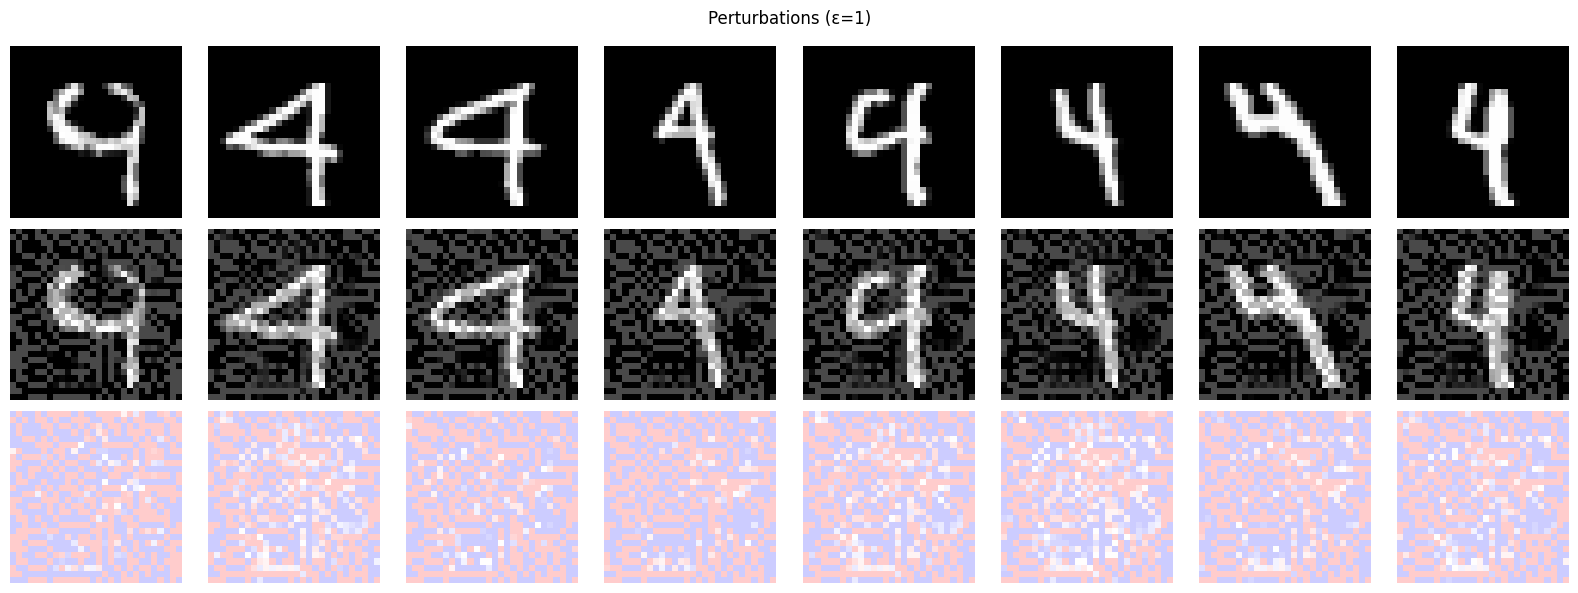

In [21]:
# Visualize perturbations
n_show = 8
fig, axes = plt.subplots(3, n_show, figsize=(16, 6))

for i in range(n_show):
    # Original
    axes[0, i].imshow(X_selected[i].cpu().reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('Original', fontsize=10)
    
    # Perturbed
    axes[1, i].imshow(X_perturbed[i].cpu().reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('Perturbed', fontsize=10)
    
    # Difference (amplified for visibility)
    diff = (X_perturbed[i] - X_selected[i]).cpu().reshape(28, 28)
    axes[2, i].imshow(diff, cmap='bwr', vmin=-args.epsilon, vmax=args.epsilon)
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_ylabel('Δ (difference)', fontsize=10)

plt.suptitle(f'Perturbations (ε={args.epsilon})', fontsize=12)
plt.tight_layout()
plt.show()